# 04 — Theory-linked analyses: embodiment, image schemas, and computational interpretation

This additional notebook links the quantitative results back to the project’s primary theoretical references.

It focuses on analyses that are especially useful for the thesis discussion:

- **Johnson (1987)** and **Lakoff & Johnson (1980):** image schemas as recurring embodied structures that support meaning and metaphor.
- **Hampe (2005):** image schemas as interpretive constructs with variation and complexity.
- **Mandler & Pagan Cánovas (2014):** caution about treating all proposed schemas as equivalent; supports analysing schema-family difficulty.
- **Wachowiak & Gromann (2022):** computational image-schema identification as an NLP task; supports measuring schema recovery and explainability.
- **Olivier & Bouraoui (2025):** image schemas as candidate neurosymbolic structures for grounded reasoning; supports the idea of image schemas as intermediate representations rather than final meanings.

The notebook deliberately avoids claiming that LLMs have embodied cognition. Instead, it asks whether LLM outputs can be structured through image-schema categories in a way that is useful, measurable, and explainable.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run these notebooks from the project notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"

RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"
COST_PATH = OUTPUTS_DIR / "cost_log.jsonl"

def read_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} at line {line_no}: {exc}") from exc
    return pd.DataFrame(records)

def safe_read_jsonl(path: Path) -> pd.DataFrame:
    return read_jsonl(path) if path.exists() else pd.DataFrame()

def clean_label(value):
    if pd.isna(value):
        return None
    return str(value).strip()

def norm_prompt_generation(prompt_id):
    if pd.isna(prompt_id):
        return "unknown"
    prompt_id = str(prompt_id)
    if "_v2_" in prompt_id or prompt_id.endswith("_v2"):
        return "v2_abstention"
    if "_v1" in prompt_id:
        return "v1"
    return "unknown"

def safe_accuracy(df: pd.DataFrame, pred_col: str, gold_col: str):
    if df.empty or pred_col not in df.columns or gold_col not in df.columns:
        return None
    sub = df[df[pred_col].notna() & df[gold_col].notna()].copy()
    if sub.empty:
        return None
    return float((sub[pred_col].astype(str) == sub[gold_col].astype(str)).mean())

def safe_rate(series):
    if series is None or len(series) == 0:
        return None
    return float(pd.Series(series).mean())

def pct(x, digits=1):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    return f"{100*x:.{digits}f}%"

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "prompt_id" in out.columns:
        out["prompt_generation"] = out["prompt_id"].map(norm_prompt_generation)
        out["uses_abstention_gate"] = out["prompt_id"].astype(str).str.contains("abstention", case=False, na=False)
    else:
        out["prompt_generation"] = "unknown"
        out["uses_abstention_gate"] = False

    if "sentence_type" in out.columns:
        out["gold_schema_present"] = np.where(out["sentence_type"].eq("control_weak_schema"), "no", "yes")
    else:
        out["gold_schema_present"] = np.nan

    if "main_image_schema" in out.columns:
        out["predicted_schema_present_from_schema"] = np.where(out["main_image_schema"].eq("NONE"), "no", "yes")
    else:
        out["predicted_schema_present_from_schema"] = np.nan

    if "schema_present" not in out.columns:
        out["schema_present"] = out["predicted_schema_present_from_schema"]

    if "literal_or_metaphorical" not in out.columns:
        out["literal_or_metaphorical"] = np.nan

    if "expected_literal_or_metaphorical" not in out.columns:
        out["expected_literal_or_metaphorical"] = np.nan

    if "main_image_schema" not in out.columns:
        out["main_image_schema"] = np.nan

    if "expected_schema_primary" not in out.columns:
        out["expected_schema_primary"] = np.nan

    out["is_control"] = out["sentence_type"].eq("control_weak_schema") if "sentence_type" in out.columns else False
    out["is_structured_json"] = out["parse_status"].eq("parsed") if "parse_status" in out.columns else False
    out["control_correct"] = out["is_control"] & out["literal_or_metaphorical"].eq("control") & out["main_image_schema"].eq("NONE")
    out["control_false_positive_schema"] = out["is_control"] & out["main_image_schema"].notna() & ~out["main_image_schema"].eq("NONE")
    out["schema_present_correct"] = out["schema_present"].eq(out["gold_schema_present"])
    out["primary_schema_correct"] = out["main_image_schema"].eq(out["expected_schema_primary"])
    out["lm_correct"] = out["literal_or_metaphorical"].eq(out["expected_literal_or_metaphorical"])
    return out

def summarize_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=group_cols + [
            "n", "parse_rate", "schema_present_accuracy", "primary_schema_accuracy",
            "literal_metaphorical_accuracy", "control_accuracy",
            "control_false_positive_schema_rate", "non_control_lm_accuracy"
        ])
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        parsed = g[g["parse_status"].eq("parsed")] if "parse_status" in g.columns else g
        controls = parsed[parsed["is_control"]]
        non_controls = parsed[~parsed["is_control"]]
        row = dict(zip(group_cols, keys))
        row.update({
            "n": len(g),
            "parsed_n": len(parsed),
            "parse_rate": len(parsed) / len(g) if len(g) else None,
            "schema_present_accuracy": safe_rate(parsed["schema_present_correct"]) if len(parsed) else None,
            "primary_schema_accuracy": safe_accuracy(parsed, "main_image_schema", "expected_schema_primary"),
            "literal_metaphorical_accuracy": safe_accuracy(parsed, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
            "control_accuracy": safe_rate(controls["control_correct"]) if len(controls) else None,
            "control_false_positive_schema_rate": safe_rate(controls["control_false_positive_schema"]) if len(controls) else None,
            "non_control_lm_accuracy": safe_rate(non_controls["lm_correct"]) if len(non_controls) else None,
        })
        rows.append(row)
    return pd.DataFrame(rows)

def display_percent_table(df: pd.DataFrame, percent_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x) if x is not None else "NA")
    return out

In [2]:
parsed = add_derived_columns(read_jsonl(PARSED_PATH))
structured = parsed[parsed["parse_status"].eq("parsed")].copy()
print(f"Structured records: {len(structured)}")

Structured records: 7200


## 1. Schema-family robustness

If image schemas were equally easy for the models, accuracy would be fairly uniform across families. If some families are much easier, this supports Mandler and Pagan Cánovas' caution that image-schema categories should not be treated as a flat, equally coherent inventory.

For the discussion, look for whether CONTAINER and SOURCE_PATH_GOAL are more robust than SUPPORT_BALANCE, FORCE, or BLOCKAGE.

In [3]:
schema_family = summarize_group(structured[~structured["is_control"]], ["expected_schema_primary", "prompt_generation"])
display(display_percent_table(schema_family, [
    "schema_present_accuracy", "primary_schema_accuracy", "literal_metaphorical_accuracy", "non_control_lm_accuracy"
]))

,expected_schema_primary,prompt_generation,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,BLOCKAGE,v1,396,396,1.0,99.2%,96.0%,99.0%,None,None,99.0%
1,BLOCKAGE,v2_abstention,396,396,1.0,100.0%,98.2%,98.5%,None,None,98.5%
2,CONTAINER,v1,414,414,1.0,100.0%,84.5%,100.0%,None,None,100.0%
3,CONTAINER,v2_abstention,414,414,1.0,100.0%,87.7%,100.0%,None,None,100.0%
4,FORCE,v1,396,396,1.0,100.0%,84.8%,100.0%,None,None,100.0%
5,FORCE,v2_abstention,396,396,1.0,100.0%,88.1%,100.0%,None,None,100.0%
6,SOURCE_PATH_GOAL,v1,414,414,1.0,100.0%,99.5%,100.0%,None,None,100.0%
7,SOURCE_PATH_GOAL,v2_abstention,414,414,1.0,99.0%,98.3%,99.0%,None,None,99.0%
8,SUPPORT_BALANCE,v1,396,396,1.0,99.2%,81.8%,98.5%,None,None,98.5%
9,SUPPORT_BALANCE,v2_abstention,396,396,1.0,100.0%,88.4%,100.0%,None,None,100.0%


prompt_generation,v1,v2_abstention
expected_schema_primary,,
BLOCKAGE,0.959596,0.982323
CONTAINER,0.845411,0.876812
FORCE,0.848485,0.881313
SOURCE_PATH_GOAL,0.995169,0.983092
SUPPORT_BALANCE,0.818182,0.883838
VERTICALITY,0.651515,0.694444


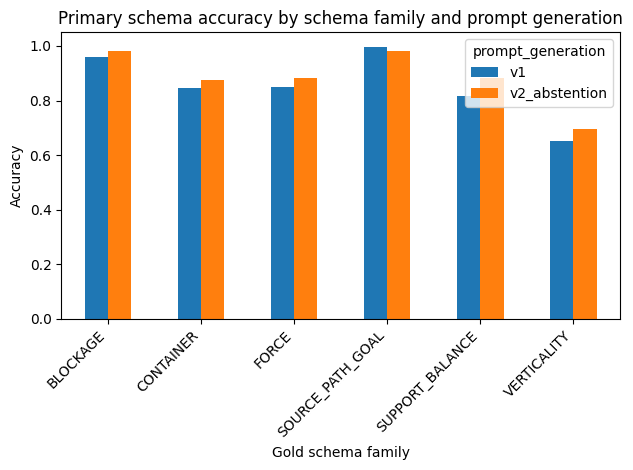

In [4]:
if not schema_family.empty:
    pivot = schema_family.pivot_table(
        index="expected_schema_primary",
        columns="prompt_generation",
        values="primary_schema_accuracy"
    )
    display(pivot)
    ax = pivot.plot(kind="bar")
    ax.set_title("Primary schema accuracy by schema family and prompt generation")
    ax.set_xlabel("Gold schema family")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 2. Abstention as a theoretical and computational control

The control condition tests whether the model can decide that an image-schema analysis is **not warranted**. This is important because cognitive-linguistic categories are powerful enough to be over-applied. A model that labels every sentence with a schema is not doing good theory; it is failing to abstain.

This analysis relates to the methodological question: does structured prompting improve theoretical interpretability, or does it simply encourage over-detection?

In [5]:
abstention_by_prompt = summarize_group(structured, ["prompt_id"])
display(display_percent_table(abstention_by_prompt, [
    "schema_present_accuracy", "control_accuracy", "control_false_positive_schema_rate", "non_control_lm_accuracy"
]))

,prompt_id,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,p_direct_schema_v1,1800,1800,1.0,80.8%,0.719444,0.807778,41.9%,58.1%,99.9%
1,p_direct_schema_v2_abstention,1800,1800,1.0,92.7%,0.859444,0.927222,78.5%,21.5%,99.8%
2,p_structured_roles_v1,1800,1800,1.0,90.7%,0.803333,0.905000,72.7%,27.3%,99.3%
3,p_structured_roles_v2_abstention,1800,1800,1.0,92.8%,0.842778,0.924444,78.3%,21.7%,99.4%


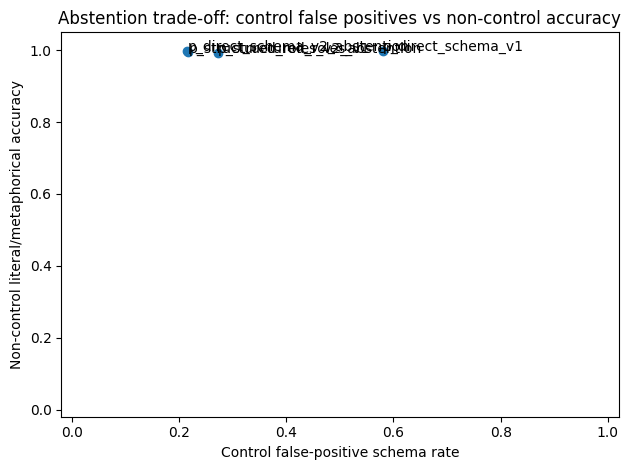

In [6]:
# Visualise the trade-off: controls vs non-controls.
tradeoff = abstention_by_prompt.dropna(subset=["control_false_positive_schema_rate", "non_control_lm_accuracy"]).copy()
if not tradeoff.empty:
    fig, ax = plt.subplots()
    ax.scatter(tradeoff["control_false_positive_schema_rate"], tradeoff["non_control_lm_accuracy"])
    for _, row in tradeoff.iterrows():
        ax.annotate(row["prompt_id"], (row["control_false_positive_schema_rate"], row["non_control_lm_accuracy"]))
    ax.set_title("Abstention trade-off: control false positives vs non-control accuracy")
    ax.set_xlabel("Control false-positive schema rate")
    ax.set_ylabel("Non-control literal/metaphorical accuracy")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    plt.tight_layout()
    plt.show()

## 3. Model agreement as evidence of representational stability

If different model providers converge on the same schema labels, that suggests the prompt is eliciting a stable linguistic pattern. If they diverge, the output may be more model-specific.

This does **not** prove embodiment. It tests whether image-schema annotation behaves as a reliable computational representation.

In [7]:
# Agreement by sentence/prompt/condition across providers.
agreement_rows = []
key_cols = ["prompt_id", "condition_id", "sentence_id", "repetition_index"]
if all(col in structured.columns for col in key_cols + ["provider", "main_image_schema"]):
    for keys, g in structured.groupby(key_cols):
        labels = g[["provider", "main_image_schema"]].dropna()
        if len(labels) < 2:
            continue
        counts = labels["main_image_schema"].value_counts()
        majority_label = counts.index[0]
        majority_rate = counts.iloc[0] / len(labels)
        agreement_rows.append({
            **dict(zip(key_cols, keys)),
            "n_providers": len(labels),
            "majority_schema": majority_label,
            "majority_agreement_rate": majority_rate,
            "unique_schema_count": labels["main_image_schema"].nunique(),
        })
agreement = pd.DataFrame(agreement_rows)
print(f"Agreement comparison rows: {len(agreement)}")
display(agreement.head())

Agreement comparison rows: 2400


,prompt_id,condition_id,sentence_id,repetition_index,n_providers,majority_schema,majority_agreement_rate,unique_schema_count
0,p_direct_schema_v1,c_temp_03_v1,s0001,0,3,CONTAINER,1.0,1
1,p_direct_schema_v1,c_temp_03_v1,s0001,1,3,CONTAINER,1.0,1
2,p_direct_schema_v1,c_temp_03_v1,s0002,0,3,CONTAINER,1.0,1
3,p_direct_schema_v1,c_temp_03_v1,s0002,1,3,CONTAINER,1.0,1
4,p_direct_schema_v1,c_temp_03_v1,s0003,0,3,CONTAINER,1.0,1


In [8]:
if not agreement.empty:
    agreement_summary = (
        agreement.groupby("prompt_id")
        .agg(
            n=("sentence_id", "count"),
            mean_majority_agreement=("majority_agreement_rate", "mean"),
            unanimous_rate=("unique_schema_count", lambda s: float((s == 1).mean()))
        )
        .reset_index()
    )
    display(display_percent_table(agreement_summary, ["mean_majority_agreement", "unanimous_rate"]))

,prompt_id,n,mean_majority_agreement,unanimous_rate
0,p_direct_schema_v1,600,83.8%,58.8%
1,p_direct_schema_v2_abstention,600,92.3%,78.0%
2,p_structured_roles_v1,600,90.2%,72.2%
3,p_structured_roles_v2_abstention,600,92.5%,78.7%


## 4. Role and domain completeness

The structured-role prompt should not only classify; it should expose intermediate semantic commitments. This is where the project connects most clearly to explainability.

A response is more interpretable if it identifies relevant roles such as trajector, landmark/container, path, goal, obstacle, force, source domain, and target domain where appropriate.

In [9]:
role_cols = ["trajector", "landmark_or_container", "source", "path", "goal", "obstacle", "force"]
domain_cols = ["source_domain", "target_domain"]

role_data = structured.copy()
for col in role_cols:
    if col not in role_data.columns:
        role_data[col] = ""
    role_data[f"{col}_filled"] = role_data[col].fillna("").astype(str).str.len() > 0

for col in domain_cols:
    if col not in role_data.columns:
        role_data[col] = [[] for _ in range(len(role_data))]
    role_data[f"{col}_filled"] = role_data[col].map(lambda x: isinstance(x, list) and len(x) > 0)

role_summary = (
    role_data.groupby(["prompt_id", "sentence_type"])
    .agg(
        n=("run_key", "count"),
        trajector_rate=("trajector_filled", "mean"),
        landmark_rate=("landmark_or_container_filled", "mean"),
        source_rate=("source_filled", "mean"),
        path_rate=("path_filled", "mean"),
        goal_rate=("goal_filled", "mean"),
        obstacle_rate=("obstacle_filled", "mean"),
        force_rate=("force_filled", "mean"),
        source_domain_rate=("source_domain_filled", "mean"),
        target_domain_rate=("target_domain_filled", "mean"),
    )
    .reset_index()
)
display(display_percent_table(role_summary, [
    "trajector_rate", "landmark_rate", "source_rate", "path_rate", "goal_rate",
    "obstacle_rate", "force_rate", "source_domain_rate", "target_domain_rate"
]))

,prompt_id,sentence_type,n,trajector_rate,landmark_rate,source_rate,path_rate,goal_rate,obstacle_rate,force_rate,source_domain_rate,target_domain_rate
0,p_direct_schema_v1,control_weak_schema,594,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.9%,5.6%
1,p_direct_schema_v1,literal_spatial,603,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,34.7%,34.0%
2,p_direct_schema_v1,metaphorical_spatial,603,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,66.7%,66.5%
3,p_direct_schema_v2_abstention,control_weak_schema,594,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,12.6%,8.6%
4,p_direct_schema_v2_abstention,literal_spatial,603,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,62.2%,29.2%
5,p_direct_schema_v2_abstention,metaphorical_spatial,603,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,99.0%,99.0%
6,p_structured_roles_v1,control_weak_schema,594,56.4%,37.2%,11.1%,12.1%,14.5%,0.8%,13.5%,13.0%,10.1%
7,p_structured_roles_v1,literal_spatial,603,98.2%,74.0%,31.3%,54.2%,42.5%,17.7%,38.5%,0.5%,0.5%
8,p_structured_roles_v1,metaphorical_spatial,603,98.3%,48.9%,46.6%,55.4%,56.9%,20.7%,48.9%,99.3%,99.0%
9,p_structured_roles_v2_abstention,control_weak_schema,594,18.9%,13.6%,5.9%,8.9%,9.9%,0.8%,6.6%,7.6%,7.1%


## 5. Discussion statements generated from analysis

Use the cells below to generate thesis-ready statements. These should be manually checked before inclusion in the final report.

In [10]:
discussion_points = []

# Control false-positive reduction
pm = summarize_group(structured, ["prompt_id"])
if not pm.empty:
    for _, row in pm.iterrows():
        if row.get("control_false_positive_schema_rate") is not None:
            discussion_points.append(
                f"{row['prompt_id']} produced a control false-positive schema rate of {pct(row['control_false_positive_schema_rate'])}."
            )

# Schema-family variation
if not schema_family.empty:
    worst = schema_family.dropna(subset=["primary_schema_accuracy"]).sort_values("primary_schema_accuracy").head(3)
    best = schema_family.dropna(subset=["primary_schema_accuracy"]).sort_values("primary_schema_accuracy", ascending=False).head(3)
    discussion_points.append("Best-performing schema-family/prompt combinations:")
    for _, r in best.iterrows():
        discussion_points.append(f"- {r['expected_schema_primary']} / {r['prompt_generation']}: {pct(r['primary_schema_accuracy'])}")
    discussion_points.append("Lowest-performing schema-family/prompt combinations:")
    for _, r in worst.iterrows():
        discussion_points.append(f"- {r['expected_schema_primary']} / {r['prompt_generation']}: {pct(r['primary_schema_accuracy'])}")

for point in discussion_points:
    print(point)

p_direct_schema_v1 produced a control false-positive schema rate of 58.1%.
p_direct_schema_v2_abstention produced a control false-positive schema rate of 21.5%.
p_structured_roles_v1 produced a control false-positive schema rate of 27.3%.
p_structured_roles_v2_abstention produced a control false-positive schema rate of 21.7%.
Best-performing schema-family/prompt combinations:
- SOURCE_PATH_GOAL / v1: 99.5%
- SOURCE_PATH_GOAL / v2_abstention: 98.3%
- BLOCKAGE / v2_abstention: 98.2%
Lowest-performing schema-family/prompt combinations:
- VERTICALITY / v1: 65.2%
- VERTICALITY / v2_abstention: 69.4%
- SUPPORT_BALANCE / v1: 81.8%


## Reference-linked interpretation

Suggested framing:

- Following Johnson and Lakoff & Johnson, the project treats image schemas as schematic structures that can organise literal and metaphorical meaning.
- Following Hampe and Mandler & Pagan Cánovas, it treats image schemas as a contested and non-uniform inventory, which justifies schema-family error analysis.
- Following Wachowiak & Gromann, it treats image-schema identification as a computational annotation problem.
- Following Olivier & Bouraoui, it treats image schemas as candidate intermediate representations for more structured reasoning, but this project tests that claim empirically at sentence level before making stronger claims about grounded agents.